In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from IPython.display import display

In [21]:
FILENAME = 'stock_report_june_21.xlsx'

In [22]:
df = pd.read_excel(FILENAME, sheet_name='Sheet1', usecols=['Name', 'Total Qty', 'CurrentStock'])
df.columns = ['Name', 'Sold_Qty', 'Current_Stock']
df['Name'] = df['Name'].astype(str).str.strip().str.title()

In [23]:
print(f"✅  Loaded {len(df)} items")
print(df.head())

✅  Loaded 663 items
                          Name  Sold_Qty  Current_Stock
0                    Egg White   182.000       -838.000
1  Linc Pentonic B-Rt Pen Blue     1.000         -9.000
2                   Vazhuthana     0.195         -5.420
3              Coconut Grinted     9.000         -4.000
4                   Veluthulli     2.265         -3.305


## Top 20 Most Sold Items

In [24]:
top20_sold = (
    df[df['Sold_Qty'] > 0]
    .nlargest(20, 'Sold_Qty')[['Name', 'Sold_Qty', 'Current_Stock']]
    .reset_index(drop=True)
)
top20_sold.index += 1

print("\n📦  TOP 20 MOST SOLD ITEMS — JUNE 21")
print("=" * 60)
display(top20_sold.style
    .format({'Sold_Qty': '{:.3f}', 'Current_Stock': '{:.3f}'})
    .set_caption("Top 20 Most Sold Items")
    .background_gradient(subset=['Sold_Qty'], cmap='Greens')
)


📦  TOP 20 MOST SOLD ITEMS — JUNE 21


,Name,Sold_Qty,Current_Stock
1,Egg White,182.000,-838.000
2,Milma Prime Milk,105.000,14.000
3,Egg Nadan,100.000,192.000
4,Muraliya Milk 450Ml,24.000,2.000
5,Milma Elite Curd 500G,22.000,-2.000
6,Cloth Bag Small,21.000,406.000
7,Savala,18.875,78.490
8,Tomato,13.540,31.135
9,Cloth Bag Big,13.000,376.000
10,Kiran,12.660,2.815


## Top 20 Least / Not Sold Items (Current Stock > 5)

In [25]:
least_sold = (
    df[df['Current_Stock'] > 5]
    .nsmallest(20, 'Sold_Qty')[['Name', 'Sold_Qty', 'Current_Stock']]
    .reset_index(drop=True)
)
least_sold.index += 1

print("\n🐌  TOP 20 LEAST / NOT SOLD ITEMS  (Stock > 5 units)")
print("=" * 60)
display(least_sold.style
    .format({'Sold_Qty': '{:.3f}', 'Current_Stock': '{:.3f}'})
    .set_caption("Least Sold Items with Stock > 5")
    .background_gradient(subset=['Current_Stock'], cmap='Oranges')
)


🐌  TOP 20 LEAST / NOT SOLD ITEMS  (Stock > 5 units)


,Name,Sold_Qty,Current_Stock
1,Red Chilli,0.100,33.300
2,Rambutan Yellow,0.250,11.690
3,Sambar Parippu (Massor Dal ),0.500,22.250
4,Cherupayar Parippu,0.500,23.500
5,Amarakka,0.525,5.735
6,Black Chana,0.755,6.995
7,Payar,0.770,5.505
8,Jaggary,0.880,15.635
9,Eastern Fish Masala 100Gm,1.000,6.000
10,Slice 250Ml,1.000,6.000


## Top 10 Negative Quantity Stocks

In [26]:
negative_stock = (
    df[df['Current_Stock'] < 0]
    .nsmallest(10, 'Current_Stock')[['Name', 'Sold_Qty', 'Current_Stock']]
    .reset_index(drop=True)
)
negative_stock.index += 1

print("\n🔴  TOP 10 MOST NEGATIVE STOCK ITEMS")
print("=" * 60)
display(negative_stock.style
    .format({'Sold_Qty': '{:.3f}', 'Current_Stock': '{:.3f}'})
    .set_caption("Items with Highest Negative Stock")
    .applymap(lambda v: 'color: red; font-weight: bold', subset=['Current_Stock'])
)


🔴  TOP 10 MOST NEGATIVE STOCK ITEMS


AttributeError: 'Styler' object has no attribute 'applymap'

## Bar Chart: Top 10 Most Sold Items

In [ ]:
top10 = df[df['Sold_Qty'] > 0].nlargest(10, 'Sold_Qty').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(13, 6))
colors = plt.cm.viridis(np.linspace(0.85, 0.3, len(top10)))
bars = ax.barh(top10['Name'][::-1], top10['Sold_Qty'][::-1], color=colors[::-1], edgecolor='white', height=0.65)

for bar, val in zip(bars, top10['Sold_Qty'][::-1]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', va='center', fontsize=10, fontweight='bold', color='#333')

ax.set_xlabel('Units Sold', fontsize=12)
ax.set_title('🏆  Top 10 Most Sold Items — June 21', fontsize=14, fontweight='bold', pad=15)
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('top10_most_sold.png', dpi=150, bbox_inches='tight')
plt.show()


## Restock Alert Table

In [ ]:
def restock_status(row):
    if row['Current_Stock'] < 0:
        return '🔴 CRITICAL'
    elif row['Current_Stock'] == 0:
        return '🟠 OUT OF STOCK'
    elif 0 < row['Current_Stock'] <= 5 and row['Sold_Qty'] > 0:
        return '🟡 LOW STOCK'
    return None

df['Restock_Status'] = df.apply(restock_status, axis=1)
restock_df = (
    df[df['Restock_Status'].notna()]
    .sort_values(['Restock_Status', 'Current_Stock'])
    [['Name', 'Sold_Qty', 'Current_Stock', 'Restock_Status']]
    .reset_index(drop=True)
)
restock_df.index += 1

print(f"\n⚠️   RESTOCK ALERT TABLE  —  {len(restock_df)} items need attention")
print(f"   🔴 CRITICAL     : {(restock_df['Restock_Status'] == '🔴 CRITICAL').sum()} items")
print(f"   🟠 OUT OF STOCK : {(restock_df['Restock_Status'] == '🟠 OUT OF STOCK').sum()} items")
print(f"   🟡 LOW STOCK    : {(restock_df['Restock_Status'] == '🟡 LOW STOCK').sum()} items")
print("=" * 70)
display(restock_df.style
    .format({'Sold_Qty': '{:.3f}', 'Current_Stock': '{:.3f}'})
    .set_caption("Items Requiring Immediate Restock")
    .applymap(lambda v: 'color: red; font-weight: bold'    if 'CRITICAL'     in str(v) else
                        'color: orange; font-weight: bold'  if 'OUT OF STOCK' in str(v) else
                        'color: goldenrod'                  if 'LOW'          in str(v) else '',
              subset=['Restock_Status'])
)
df.drop(columns=['Restock_Status'], inplace=True)

## Daily Sales Graph + Trendline

In [27]:
daily_sales = {
    'Mon Jun 16': 52916.00,    
    'Tue Jun 17': 47763.00,
    'Wed Jun 18': 62355.00,
    'Thu Jun 19': 47165.00,
    'Fri Jun 20': 61661.00,
    'Sat Jun 21': 89715.00,   
    'Sun Jun 22': 66447.00,
}

days  = list(daily_sales.keys())
sales = list(daily_sales.values())
x     = np.arange(len(days))

z     = np.polyfit(x, sales, 1)
trend = np.poly1d(z)

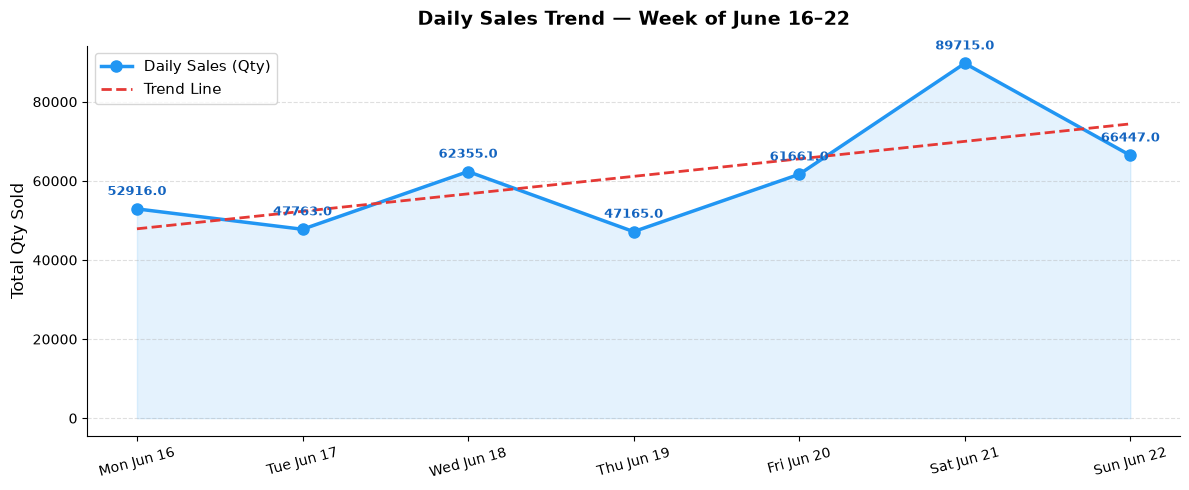


📊  Jun 21 total qty sold (from file): 1659.08


In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(days, sales, marker='o', linewidth=2.5, color='#2196F3', markersize=8, label='Daily Sales (Qty)')
ax.fill_between(days, sales, alpha=0.12, color='#2196F3')
ax.plot(days, trend(x), linestyle='--', color='#E53935', linewidth=2, label='Trend Line')

for i, (d, s) in enumerate(zip(days, sales)):
    ax.annotate(f'{s:.1f}', (d, s), textcoords='offset points', xytext=(0, 10),
                ha='center', fontsize=9, fontweight='bold', color='#1565C0')

ax.set_title('Daily Sales Trend — Week of June 16–22', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Total Sales', fontsize=12)
ax.legend(fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.savefig('daily_sales_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n📊  Jun 21 total qty sold (from file): {df['Sold_Qty'].sum():.2f}")

## Highest & Lowest Sales Day Suggestion

In [ ]:
sales_series    = pd.Series(daily_sales)
sales_non_zero  = sales_series[sales_series > 0]

print("\n📅  WEEKLY SALES SUMMARY")
print("=" * 50)

if sales_non_zero.empty:
    print("⚠️  No daily sales data entered yet.")
    print("   Fill in the `daily_sales` dictionary in Block 6")
    print("   with your actual daily totals, then re-run Blocks 6 & 7.")
else:
    highest_day = sales_non_zero.idxmax()
    lowest_day  = sales_non_zero.idxmin()
    avg_sales   = sales_non_zero.mean()

    for day, qty in sales_series.items():
        tag = ''
        if day == highest_day: tag = '  ← 🟢 HIGHEST'
        if day == lowest_day:  tag = '  ← 🔴 LOWEST'
        print(f"  {day:<14}  {qty:>8.2f} units{tag}")

    print("-" * 50)
    print(f"  Weekly Total  :  {sales_non_zero.sum():.2f} units")
    print(f"  Daily Average :  {avg_sales:.2f} units")
    print()
    print(f"  🟢  Highest sales day : {highest_day}  ({sales_non_zero[highest_day]:.2f} units)")
    print(f"  🔴  Lowest  sales day : {lowest_day}   ({sales_non_zero[lowest_day]:.2f} units)")

    fig, ax = plt.subplots(figsize=(11, 5))
    bar_colors = ['#66BB6A' if d == highest_day
                  else '#EF5350' if d == lowest_day
                  else '#90CAF9' for d in days]
    ax.bar(days, sales, color=bar_colors, edgecolor='white', width=0.6)
    ax.axhline(avg_sales, color='#FFA726', linewidth=2, linestyle='--', label=f'Avg: {avg_sales:.1f}')

    for i, (d, s) in enumerate(zip(days, sales)):
        if s > 0:
            ax.text(i, s + avg_sales * 0.02, f'{s:.1f}', ha='center',
                    fontsize=9, fontweight='bold', color='#333')

    ax.set_title('📅  Day-wise Sales — Green=Highest | Red=Lowest | Blue=Others',
                 fontsize=13, fontweight='bold', pad=12)
    ax.set_ylabel('Daily Sales', fontsize=12)
    ax.legend(fontsize=11)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.35)
    ax.tick_params(axis='x', rotation=15)
    plt.tight_layout()
    plt.savefig('day_sales_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()